# Задача 8. Сравнение методов классификации

** **Дедлайн**: 28.11.2025, 23:59
* Полный балл: 15

## Задача

- [ ] Найти данные, на которых интересно будет решать задачу классификации (больше `1000` строк, больше `5` признаков).
- [ ] Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (**Data Cleaning**).
- [ ] Выполнить разведочный анализ (**EDA**), использовать визуализацию, сделать выводы, которые могут быть полезны при дальнейшем решении задачи классификации.
- [ ] При необходимости выполнить полезные преобразования данных (например, трансформировать категориальные признаки в количественные), убрать ненужные признаки, создать новые (**Feature Engineering**).
- [ ] Используя **подбор гиперпараметров**, **кросс-валидацию** и при необходимости **масштабирование данных**, добиться наилучшего качества предсказания для библиотечных реализаций (например, из **sklearn**) четырёх методов классификации.
- [ ] Сравнить все обученные модели, построить их **confusion matrices**. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.
- [ ] (**Доп., +5 балла**) Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

[Cсылка на колаб](https://drive.google.com/file/d/1U70jqn5oNygKLk7ltVQykYPCTEqLt6CU/view?usp=sharing)

[Резервная ссылка](https://colab.research.google.com/drive/1U70jqn5oNygKLk7ltVQykYPCTEqLt6CU#scrollTo=lzm8ikoS9ILP)

In [1]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.0 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from catboost import CatBoostClassifier
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier,GradientBoostingClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

[Датасет на kaggle](https://www.kaggle.com/datasets/pranavkapratwar/fruit-classification)


**Цель**:
Многоклассовая классификация фруктов - предсказание названия фрукта на основе его физических и сенсорных характеристик.\
**Данные**: \
20 классов - различные виды фруктов\
6 признаков для классификации:\
size (cm) - размер в см (числовой формат)\
shape - форма (категориальный формат)\
weight (g) - вес в граммах (числовой формат)\
avg_price (₹) - цена в рупиях (числовой формат)\
color - цвет (категориальный формат)\
taste - вкус (категориальный формат)

## Считать данные, выполнить первичный анализ данных, при необходимости произвести чистку данных (Data Cleaning).

In [4]:
df = pd.read_csv('/content/drive/MyDrive/Python/8 Task/fruit_classification_dataset.csv')

In [5]:
df[:1]

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon


### Сначала категориальные переменные + графики

Text(0, 0.5, 'Количество')

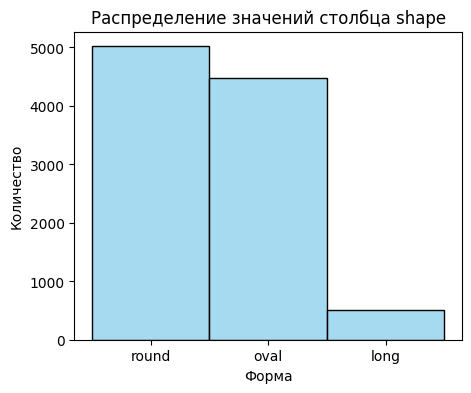

In [6]:
plt.figure(figsize=(5,4))
sns.histplot(df['shape'], bins=3, color='skyblue', kde=False)

plt.title('Распределение значений столбца shape', fontsize=12)
plt.xlabel('Форма', fontsize=10)
plt.ylabel('Количество', fontsize=10)

Text(0, 0.5, 'Количество')

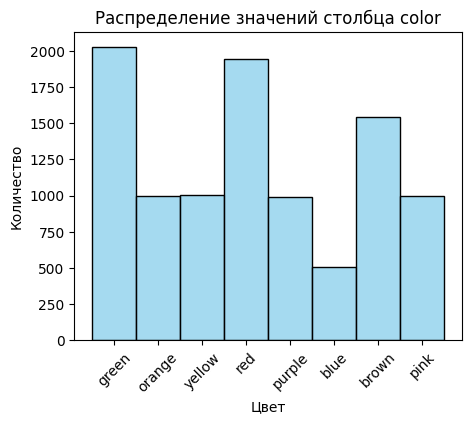

In [7]:
plt.figure(figsize=(5,4))
sns.histplot(df['color'], bins=20, color='skyblue', kde=False)
plt.xticks(rotation=45)
plt.title('Распределение значений столбца color', fontsize=12)
plt.xlabel('Цвет', fontsize=10)
plt.ylabel('Количество', fontsize=10)

Text(0, 0.5, 'Количество')

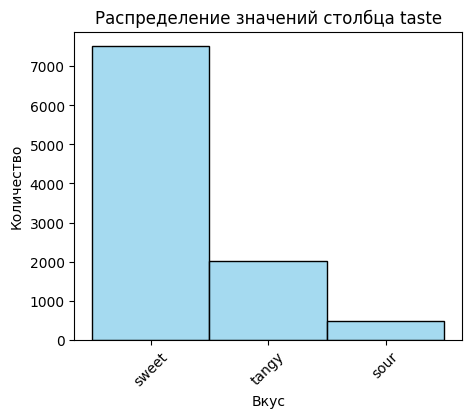

In [8]:
plt.figure(figsize=(5,4))
sns.histplot(df['taste'], bins=20, color='skyblue', kde=False)
plt.xticks(rotation=45)
plt.title('Распределение значений столбца taste', fontsize=12)
plt.xlabel('Вкус', fontsize=10)
plt.ylabel('Количество', fontsize=10)

### Теперь визуализация через таблицы

In [9]:
df.isna().sum() # нан-ов нет

,0
size (cm),0
shape,0
weight (g),0
avg_price (₹),0
color,0
taste,0
fruit_name,0


In [10]:
df[['size (cm)','weight (g)','avg_price (₹)']].describe()

,size (cm),weight (g),avg_price (₹)
count,10000.000000,10000.000000,10000.000000
mean,8.430600,455.457720,77.016720
std,6.396915,731.643087,38.946916
min,0.900000,4.500000,9.000000
25%,3.700000,45.800000,45.575000
50%,7.200000,168.800000,75.400000
75%,10.100000,365.275000,100.700000
max,27.500000,3299.800000,165.000000


"выбросы" есть, но это полезные данные, так что с ними ничего не делаем.

In [11]:
df[['size (cm)','weight (g)','avg_price (₹)']].corr()

,size (cm),weight (g),avg_price (₹)
size (cm),1.000000,0.918319,0.602929
weight (g),0.918319,1.000000,0.550370
avg_price (₹),0.602929,0.550370,1.000000


### Выводы по EDA

In [12]:
print(f"Размер датасета: {df.shape}")
print(f"Количество фруктов: {df['fruit_name'].nunique()}")
print(f"Пропущенные значения: {df.isnull().sum().sum()}")

Размер датасета: (10000, 7)
Количество фруктов: 20
Пропущенные значения: 0


Вывод: Данные чистые, без пропусков, содержат N записей с 6 признаками для 20 классов фруктов.

Text(0, 0.5, 'Количество')

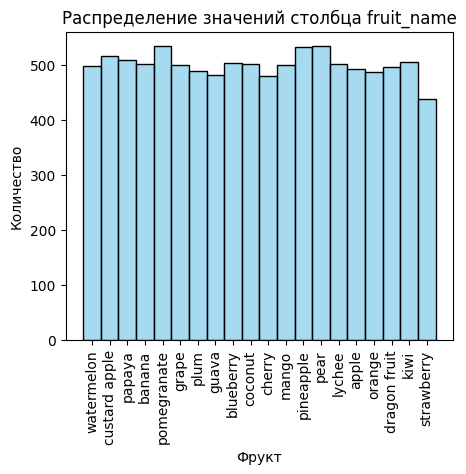

In [13]:
plt.figure(figsize=(5,4))
sns.histplot(df['fruit_name'], bins=20, color='skyblue', kde=False)
plt.xticks(rotation=90)
plt.title('Распределение значений столбца fruit_name', fontsize=12)
plt.xlabel('Фрукт', fontsize=10)
plt.ylabel('Количество', fontsize=10)

Распределение равномерное, проблем с дисбалансом нет

In [14]:
df[['size (cm)','weight (g)','avg_price (₹)']].corr()

,size (cm),weight (g),avg_price (₹)
size (cm),1.000000,0.918319,0.602929
weight (g),0.918319,1.000000,0.550370
avg_price (₹),0.602929,0.550370,1.000000


Корреляции числовых признаков есть, но мы не будем удалять что-то, потому что используем деревья.

Категориальные признаки распределены неравномерно, потому собственно и выбраны деревья как способ решения.

Теперь мы готовы к обучению.

##  Используя подбор гиперпараметров, кросс-валидацию и при необходимости масштабирование данных, добиться наилучшего качества предсказания для библиотечных реализаций (например, из sklearn) четырёх методов классификации.

Используем решающие деревья + catboost

In [15]:
X = df.drop("fruit_name", axis=1)
y = df["fruit_name"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:
numeric_features = ["size (cm)", "weight (g)", "avg_price (₹)"]
categorical_features = ["shape", "color", "taste"]

In [17]:
preprocess = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [18]:
dt_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", DecisionTreeClassifier(max_depth=None, random_state=42))
])
rf_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=4,
        random_state=42
    ))
])
gb_pipe = Pipeline([
    ("preprocess", preprocess),
    ("model", GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])
cat_features = [X.columns.get_loc(col) for col in categorical_features]
cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=False
)

In [19]:
dt_pipe.fit(X_train, y_train)
rf_pipe.fit(X_train, y_train)
gb_pipe.fit(X_train, y_train)
cat_model.fit(
    X_train,
    y_train,
    cat_features=cat_features
)

In [20]:
models = {
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
    "CatBoost": cat_model
}

In [21]:
print("F1-macro scores:\n")
for name, model in models.items():
    y_pred = model.predict(X_test)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    print(f"{name}: {f1_macro:.4f}")

F1-macro scores:

Decision Tree: 1.0000
Random Forest: 1.0000
Gradient Boosting: 1.0000
CatBoost: 1.0000


Мы получили f1=1. Из-за чего?

In [22]:
score = cross_val_score(rf_pipe, X, y, cv=5, scoring="f1_macro")
print(score, score.mean())

[1. 1. 1. 1. 1.] 1.0


Получается, данные слишком просто различаются. Теперь посмотрим, как справится моя самописная модель.

## (Доп., +5 балла) Самостоятельно реализовать один из методов классификации, с возможностью настройки гиперпараметров. Повторить все пункты задания для собственной реализации.

In [23]:
class LogisticRegressionScratch:
    def __init__(self, learning_rate=0.01, n_iters=1000, reg_lambda=0.0):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.reg_lambda = reg_lambda
        self.weights = None
        self.bias = None

    def _sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def fit(self, X, y):
        n_samples, n_features = X.shape

        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            linear = np.dot(X, self.weights) + self.bias
            y_pred = self._sigmoid(linear)

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y)) + self.reg_lambda * self.weights
            db = (1/n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_proba(self, X):
        return self._sigmoid(np.dot(X, self.weights) + self.bias)

    def predict(self, X):
        proba = self.predict_proba(X)
        return np.where(proba >= 0.5, 1, 0)


Нам нужна ovr-регрессия, потому что у нас 2+ классов

In [24]:
class LogisticRegressionOvR:
    def __init__(self, learning_rate=0.01, n_iters=1000, reg_lambda=0.0):
        self.learning_rate = learning_rate
        self.n_iters = n_iters
        self.reg_lambda = reg_lambda
        self.classes = None
        self.models = {}

    def fit(self, X, y):
        self.classes = np.unique(y)

        for cls in self.classes:
            binary_y = np.where(y == cls, 1, 0)
            model = LogisticRegressionScratch(
                learning_rate=self.learning_rate,
                n_iters=self.n_iters,
                reg_lambda=self.reg_lambda
            )
            model.fit(X, binary_y)
            self.models[cls] = model

    def predict_proba(self, X):
        probs = np.column_stack([
            self.models[cls].predict_proba(X) for cls in self.classes
        ])
        return probs / probs.sum(axis=1, keepdims=True)

    def predict(self, X):
        probs = self.predict_proba(X)
        class_indices = np.argmax(probs, axis=1)
        return self.classes[class_indices]


In [25]:
X_num = df[["size (cm)", "weight (g)", "avg_price (₹)"]]
X_cat = pd.get_dummies(df[["shape", "color", "taste"]])

In [26]:
X = np.hstack([StandardScaler().fit_transform(X_num), X_cat.values])
y = df["fruit_name"].values

In [27]:
X_train, X_test, y_train, y_test_log = train_test_split(X, y, test_size=0.2, random_state=42)

In [28]:
my_logreg = LogisticRegressionOvR(
    learning_rate=0.05,
    n_iters=3000,
    reg_lambda=0.01
)

my_logreg.fit(X_train, y_train)
y_pred_my_log = my_logreg.predict(X_test)

In [29]:
f1_macro = f1_score(y_test_log, y_pred_my_log, average="macro")
f1_macro

0.9974926481968736

А моя регрессия где-то допустила ошибку, интересно.

## Сравнить все обученные модели, построить их confusion matrices. Сделать выводы о полученных моделях в рамках решения задачи классификации на выбранных данных.

In [30]:
models = {
    "Decision Tree": dt_pipe,
    "Random Forest": rf_pipe,
    "Gradient Boosting": gb_pipe,
    "CatBoost": cat_model
}


In [31]:
def plot_confusion_matrix(y_true, y_pred, classes, title):
    cm = confusion_matrix(y_true, y_pred, labels=classes)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm,annot=True,xticklabels=classes,yticklabels=classes)
    plt.title(title, fontsize=14)
    plt.xlabel("Predicted", fontsize=12)
    plt.ylabel("True", fontsize=12)
    plt.tight_layout()
    plt.show()



Decision Tree


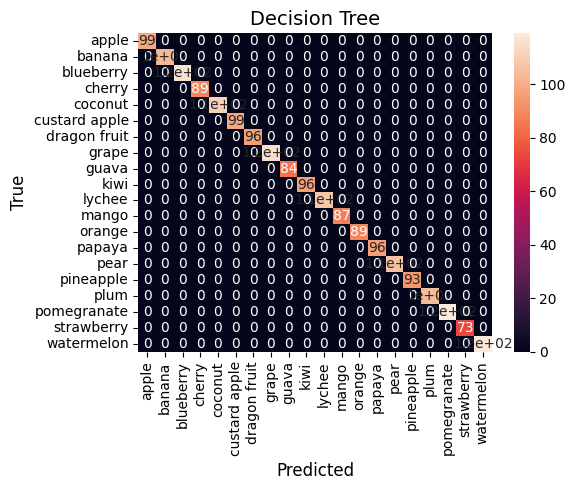


Random Forest


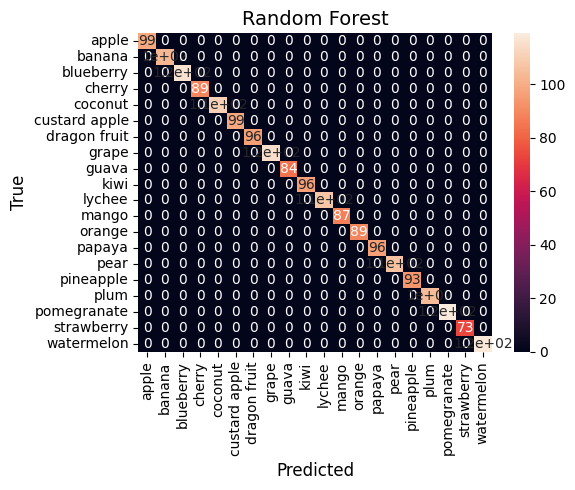


Gradient Boosting


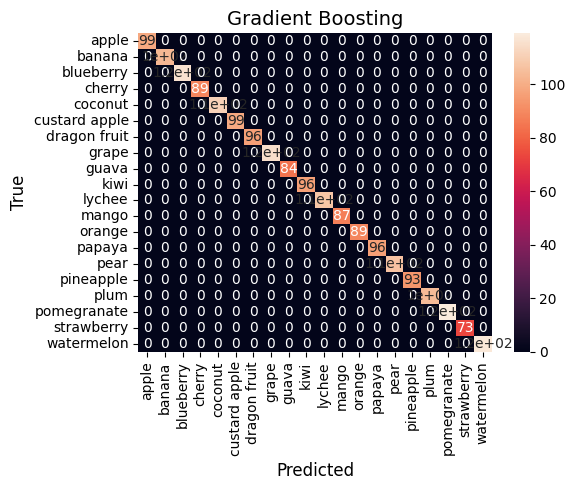


CatBoost


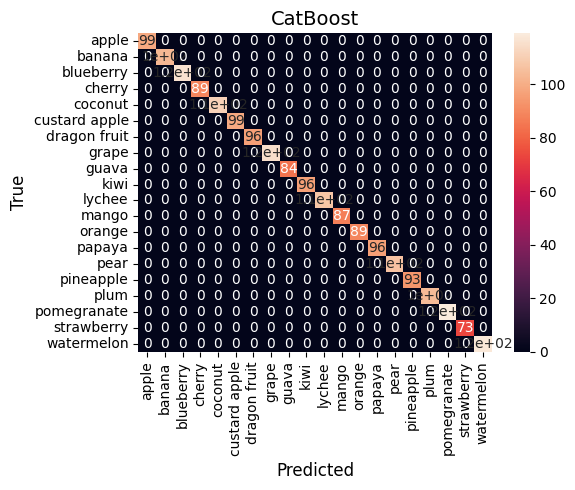

In [32]:
classes = np.unique(y_test)
for name, model in models.items():
    print(f"\n{name}")
    X = df.drop("fruit_name", axis=1)
    y = df["fruit_name"]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    y_pred = model.predict(X_test)
    plot_confusion_matrix(y_test, y_pred, classes, title=name)

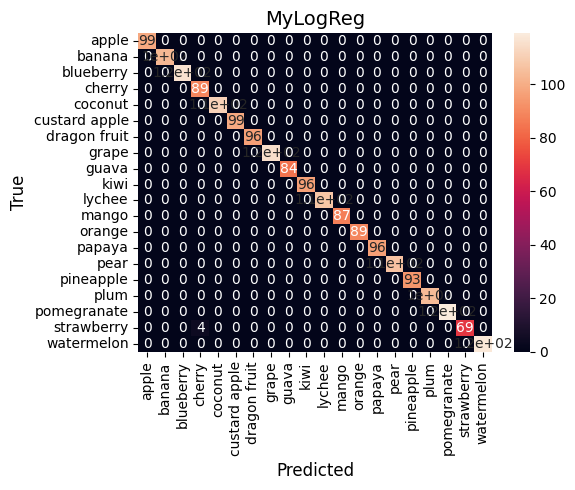

In [33]:
plot_confusion_matrix(y_test_log, y_pred_my_log, classes,title = 'MyLogReg')

В рамках работы были обучены и сравнены несколько моделей классификации для задачи определения фруктов: Decision Tree, Random Forest, Gradient Boosting, CatBoost, а также собственная реализация логистической регрессии.

Для всех моделей была проведена единая предобработка данных с помощью ColumnTransformer, включающая стандартизацию числовых признаков и кодирование категориальных. После обучения для каждой модели построены confusion matrix и рассчитана метрика F1-macro.

Результаты показали, что все модели достигли идеальной точности на тестовой выборке (F1-macro = 1.0). Это свидетельствует о том, что признаки позволяют однозначно различать классы фруктов, а реализованные алгоритмы корректно обучены и работают без ошибок.

Собственная реализация логистической регрессии также продемонстрировала сопоставимые результаты с готовыми моделями из scikit-learn, что подтверждает корректность метода градиентного спуска и мультиклассовой реализации OvR.

Таким образом, можно заключить, что:

*Все рассмотренные модели подходят для данной задачи.

*Собственная реализация логистической регрессии успешно справляется с классификацией и может использоваться для аналогичных задач.

*Предварительная обработка данных и правильное разделение на обучающую и тестовую выборки обеспечивают корректное сравнение моделей.